# DQN Tutorial

In [1]:
import gymnasium as gym

import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import HTML

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    
from learn_frame import LearningFrame
from models.rl.dqn import DQN
from data.envdata import EnvData

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



## Data

In [2]:
#Create gym environment
env = gym.make("CartPole-v1", render_mode="rgb_array")

#Get observation and action dimentions
obs, act = env.observation_space.shape[-1], env.action_space.n
#Create our data object
data = EnvData(env = env, buffer_size = 10000, batch_size = 128, start_size = 128, device= device)


## Model

In [3]:
DQN.print_args()

        arch_params = {
            "layers":[],
            "blocks":[],
            "block_args":[],
            "out_act":<class 'torch.nn.modules.activation.ReLU'>,
            "out_params":{},
            "weight_init":None,
        }
            Scheduler_params = {
                "optimizer",
                "scheduler",
                "auto_step":True,
                "**kwargs",
            }
        Optimizer_params = {
            "model",
            "optimizer":<class 'torch.optim.adamw.AdamW'>,
            "optimizer_args":{},
            "clipper":None,
            "clipper_params":{},
            "scheduler_params":None,
        }
    Network_params = {
        "arch_params",
        "decoder_params":None,
        "task":'reg',
        "optimizer_params":{},
    }
    Epsilon_params = {
        "eps":0.9,
        "eps_end":0.05,
        "eps_decay":1000,
        "random_generator":None,
    }
DQN_params = {
    "network_params",
    "gamma":0.99,
    "tau":0.005,
    

In [7]:
layers = [obs,128,128,act]
lr = 1e-3
tau = 0.005


Scheduler_params = {
    "scheduler" : optim.lr_scheduler.StepLR,
    "gamma":0.1**(1/100),
    "auto_step":False,
    "step_size" : 1
}
arch_params = {
    "layers":layers,
    "blocks":[nn.Linear, nn.ReLU],
    "block_args":[],
    "out_act":nn.Identity,
    "out_params":{},
    "weight_init":None,
}
Optimizer_params = {
    "optimizer":optim.AdamW,
    "optimizer_args":{"lr" : lr, "amsgrad" : True},
    "clipper":torch.nn.utils.clip_grad_value_,
    "clipper_params":{"clip_value" : 100},
    "scheduler_params":Scheduler_params,
}
Network_params = {
    "arch_params" : [arch_params],
    "decoder_params":None,
    "task":'reg',
    "optimizer_params":Optimizer_params,
}
Epsilon_params = {
    "eps":0.9,
    "eps_end":0.05,
    "eps_decay":1000,
    "random_generator":env.action_space.sample,
}
DQN_params = {
    "network_params" : Network_params,
    "gamma":0.99,
    "tau":0.005,
    "eps_params":Epsilon_params,
    "variant":'DQN',
    "device":device,
    "criterion":nn.SmoothL1Loss(),
}



model = DQN(**DQN_params)
#model = Discrete_SAC.load(path="checkpoint/sac.pt")
lf = LearningFrame(model,data)



### Or load

In [5]:
lf = LearningFrame(model = None, data = data)
lf.load(file_name = "../checkpoints/dqn", model = DQN, load_data = True)

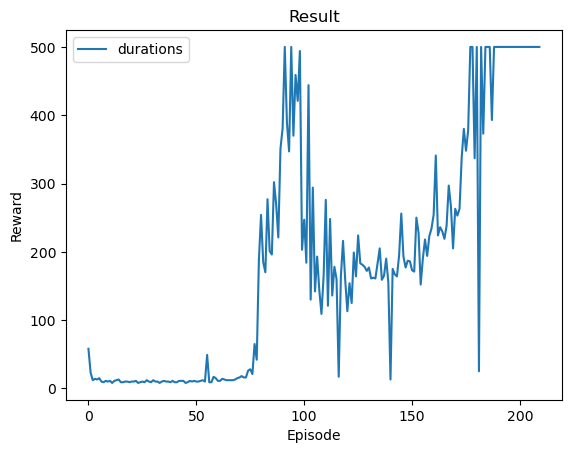

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [6]:
for i in range(10):
    done = False
    while not done:
        done = lf.collect()
        lf.optimize()
    lf.model.scheduler_step()
    if i % 10 == 0 :
        lf.plot([lf.duration_data], labels = ["durations"])
lf.plot([lf.duration_data], labels = ["durations"], show_result= True)

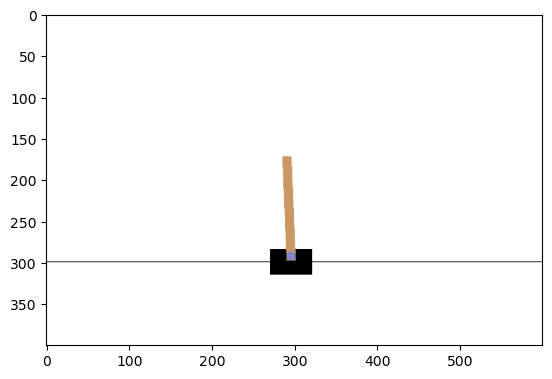

In [7]:
anim = lf.get_anim()
HTML(anim.to_jshtml())